# Adversarial Validation as a Stationarity Test
### From the confusion matrix → ROC → AUC → feature-drift detection

> **The one-sentence story.** AUC measures how separable two groups are. If you relabel
> your data by *time* — "early" vs "late" — and a feature's AUC against that label is near
> **0.5**, the feature looks the same in both periods (it is **stationary**, safe to keep).
> If the AUC is far from 0.5, the feature has **drifted** and your train-period model will
> mis-describe the test period.

This notebook builds the whole chain from first principles:

1. **Confusion matrix → TPR & FPR** — what one threshold gives you.
2. **ROC curve** — sweep every threshold at once.
3. **AUC as an integral** — and its beautiful probabilistic meaning $P(S_1 > S_0)$.
4. **Mann–Whitney U** — the from-scratch estimator, and why AUC only cares about *ranks*.
5. **Why 0.5 is the null** — and how we repurpose it into a drift detector.
6. **The blind spot** — symmetric variance blow-ups, and pairing AUC with a Wasserstein check.

---

> 💡 **Quant-interview radar.** Nearly every item here is a recurring interview topic:
> the meaning of ROC/AUC, the $P(S_1>S_0)$ identity, the Mann–Whitney connection, rank
> invariance, and **feature/data drift in backtests**. I'll flag each one as 🎯 when it appears.


## 0 · Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = {
    "pos":  "tomato",      # positive class / "late" block
    "neg":  "steelblue",   # negative class / "early" block
    "good": "mediumseagreen",
    "warn": "darkorange",
    "ink":  "navy",
}
print("ready")

ready


## 1 · The confusion matrix and the two rates

You have a **score** $s(x)$ (a real number — higher = "more likely positive") and a
**threshold** $\tau$. The decision rule is dead simple:

$$\text{predict positive} \iff s(x) \ge \tau.$$

Compare predictions to the truth $y \in \{0,1\}$ and you get four counts:

| | predicted $+$ | predicted $-$ |
|---|---|---|
| **actual $+$** | TP (hit) | FN (miss) |
| **actual $-$** | FP (false alarm) | TN (correct reject) |

Let $P = \text{TP}+\text{FN}$ = *all real positives*, and $N = \text{FP}+\text{TN}$ = *all real negatives*.
The ROC curve lives on two rates:

$$
\text{TPR}(\tau) = \frac{\text{TP}}{\underbrace{\text{TP}+\text{FN}}_{P}}, \qquad
\text{FPR}(\tau) = \frac{\text{FP}}{\underbrace{\text{FP}+\text{TN}}_{N}}.
$$

**Read these as conditional probabilities** — this is the whole intuition:

$$
\text{TPR}(\tau) = \widehat{P}(s \ge \tau \mid y=1) \;\;(\text{of the positives, what fraction did we catch?})
$$
$$
\text{FPR}(\tau) = \widehat{P}(s \ge \tau \mid y=0) \;\;(\text{of the negatives, what fraction did we wrongly flag?})
$$

> **Key insight:** TPR normalizes by the *positives only*; FPR by the *negatives only*. Each
> rate looks at one row of the matrix, so **class imbalance never distorts them** — that is
> exactly why ROC/AUC survive heavy imbalance where raw accuracy lies. 🎯


In [ ]:
def confusion(scores, y, tau):
    '''Counts (TP, FP, FN, TN) for threshold tau on a 'predict + if score >= tau' rule.'''
    pred = scores >= tau
    TP = np.sum(pred & (y == 1))
    FP = np.sum(pred & (y == 0))
    FN = np.sum(~pred & (y == 1))
    TN = np.sum(~pred & (y == 0))
    return TP, FP, FN, TN

def tpr_fpr(scores, y, tau):
    TP, FP, FN, TN = confusion(scores, y, tau)
    tpr = TP / (TP + FN) if (TP + FN) else 0.0
    fpr = FP / (FP + TN) if (FP + TN) else 0.0
    return tpr, fpr

# Toy example: two overlapping Gaussians of scores
s_pos = rng.normal(1.2, 1.0, 400)   # positives score higher on average
s_neg = rng.normal(0.0, 1.0, 400)
scores = np.concatenate([s_pos, s_neg])
y      = np.concatenate([np.ones(400), np.zeros(400)]).astype(int)

for tau in [-1.0, 0.6, 2.0]:
    TP, FP, FN, TN = confusion(scores, y, tau)
    tpr, fpr = tpr_fpr(scores, y, tau)
    print(f"tau={tau:+.1f} | TP={TP:3d} FP={FP:3d} FN={FN:3d} TN={TN:3d}"
          f" | TPR={tpr:.3f} FPR={fpr:.3f}")

tau=-1.0 | TP=396 FP=330 FN=  4 TN= 70 | TPR=0.990 FPR=0.825
tau=+0.6 | TP=288 FP= 90 FN=112 TN=310 | TPR=0.720 FPR=0.225
tau=+2.0 | TP= 69 FP=  5 FN=331 TN=395 | TPR=0.172 FPR=0.013


Watch the trade-off: a **low** threshold flags almost everything (high TPR *and* high
FPR — trigger-happy); a **high** threshold flags almost nothing (low FPR *and* low TPR —
overly cautious). One threshold = one operating point. We want to see them *all*.

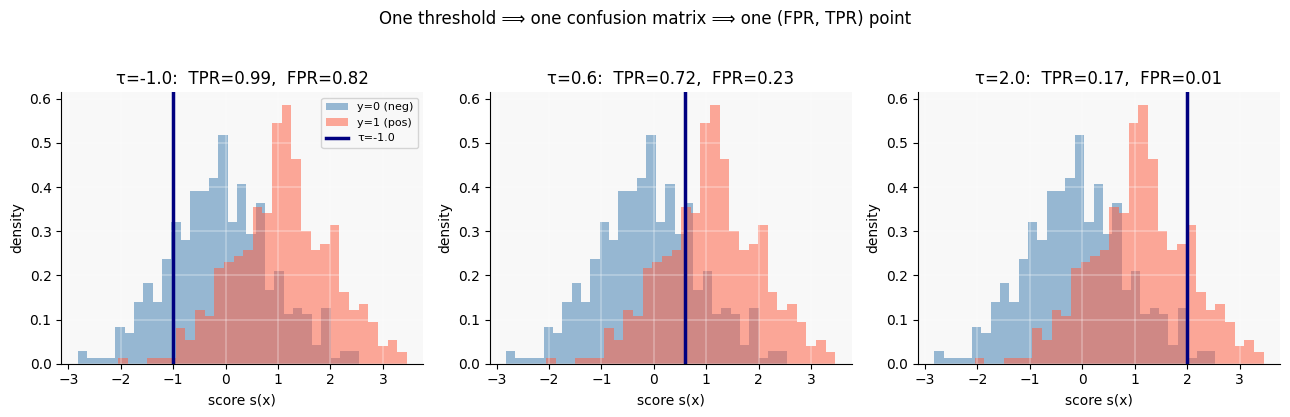

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
grid = np.linspace(-4, 5, 400)
for ax, tau in zip(axes, [-1.0, 0.6, 2.0]):
    ax.hist(s_neg, bins=30, density=True, color=PALETTE["neg"], alpha=0.55, label="y=0 (neg)")
    ax.hist(s_pos, bins=30, density=True, color=PALETTE["pos"], alpha=0.55, label="y=1 (pos)")
    ax.axvline(tau, color=PALETTE["ink"], lw=2.5, label=f"τ={tau}")
    tpr, fpr = tpr_fpr(scores, y, tau)
    ax.set_title(f"τ={tau}:  TPR={tpr:.2f},  FPR={fpr:.2f}")
    ax.set_xlabel("score s(x)"); ax.set_ylabel("density")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle("One threshold ⟹ one confusion matrix ⟹ one (FPR, TPR) point", y=1.03)
plt.tight_layout(); plt.show()

## 2 · The ROC curve = sweep every threshold

Let $f_1(s)$ and $f_0(s)$ be the score densities of the positive / negative classes. Define
the **upper tails**:

$$
G_1(\tau)=\int_\tau^\infty f_1(s)\,ds=\text{TPR},\qquad
G_0(\tau)=\int_\tau^\infty f_0(s)\,ds=\text{FPR}.
$$

Think of $G_1(\tau)$ as "what fraction of positives sit above the bar $\tau$." As we **drag the
bar $\tau$ from $+\infty$ down to $-\infty$**, the point $\big(G_0(\tau),G_1(\tau)\big)$ traces a path
from $(0,0)$ — bar so high nothing passes — to $(1,1)$ — bar so low everything passes.

That path **is** the ROC curve: a *threshold-free* picture of separability, because it shows
every operating point simultaneously.

> **Analogy:** ROC is like photographing a high-jumper at *every* bar height in one exposure.
> You no longer argue about which single height is "fair" — you see the whole performance.


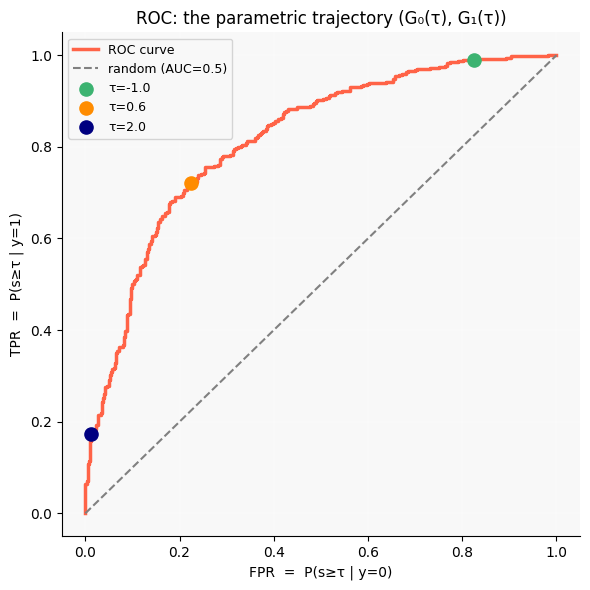

In [ ]:
def roc_curve_scratch(scores, y):
    '''Return (fpr, tpr) arrays by sweeping thresholds from high to low.'''
    order = np.argsort(-scores)            # descending score
    s_sorted = scores[order]
    y_sorted = y[order]
    P = np.sum(y == 1); N = np.sum(y == 0)
    # cumulative hits as we lower the threshold past each point
    tps = np.cumsum(y_sorted == 1)
    fps = np.cumsum(y_sorted == 0)
    tpr = np.concatenate([[0], tps / P])
    fpr = np.concatenate([[0], fps / N])
    return fpr, tpr

fpr, tpr = roc_curve_scratch(scores, y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color=PALETTE["pos"], lw=2.5, label="ROC curve")
ax.plot([0, 1], [0, 1], "--", color="gray", label="random (AUC=0.5)")
# mark the three operating points from section 1
for tau, c in zip([-1.0, 0.6, 2.0], [PALETTE["good"], PALETTE["warn"], PALETTE["ink"]]):
    t, f = tpr_fpr(scores, y, tau)
    ax.scatter([f], [t], color=c, s=90, zorder=5, label=f"τ={tau}")
ax.set_xlabel("FPR  =  P(s≥τ | y=0)")
ax.set_ylabel("TPR  =  P(s≥τ | y=1)")
ax.set_title("ROC: the parametric trajectory (G₀(τ), G₁(τ))")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3 · AUC as an integral — and what it *really* means

The Area Under the ROC Curve:

$$\text{AUC}=\int_0^1 \text{TPR}\;d(\text{FPR}).$$

Change variables back to $\tau$. Since $\dfrac{d}{d\tau}G_0(\tau)=-f_0(\tau)$, and as FPR runs
$0\to1$ the threshold runs $\tau:\infty\to-\infty$:

$$
\text{AUC}
=\int_{\infty}^{-\infty} G_1(\tau)\,\frac{dG_0}{d\tau}\,d\tau
=\int_{-\infty}^{\infty} G_1(\tau)\,f_0(\tau)\,d\tau
=\int_{-\infty}^{\infty}\!\!\Big[\int_\tau^\infty f_1(s)\,ds\Big] f_0(\tau)\,d\tau .
$$

The double integral covers exactly the region $\{s>\tau\}$ — every pair where a **positive's
score beats a negative's score**:

$$
\boxed{\;\text{AUC}=\iint_{s>\tau} f_1(s)\,f_0(\tau)\,ds\,d\tau = P\big(S_1>S_0\big)\;}
$$

with $S_1\sim f_1,\;S_0\sim f_0$ drawn **independently**.

> **Key insight (🎯 the single most-asked AUC fact):** *AUC is the probability that a randomly
> drawn positive outranks a randomly drawn negative.* It is a pure **ranking** statistic — no
> threshold, no calibration, just "who's higher?"

Let's verify the identity numerically by brute-forcing $P(S_1>S_0)$ over all pos–neg pairs.


In [ ]:
def auc_trapezoid(scores, y):
    fpr, tpr = roc_curve_scratch(scores, y)
    return np.trapezoid(tpr, fpr)          # area under the staircase

def auc_pairwise(scores, y):
    '''Direct estimate of P(S1 > S0) over all positive-negative pairs (+ 1/2 for ties).'''
    pos = scores[y == 1][:, None]      # column
    neg = scores[y == 0][None, :]      # row
    wins  = np.sum(pos > neg)
    ties  = np.sum(pos == neg)
    return (wins + 0.5 * ties) / (pos.size * neg.size)

print(f"AUC via trapezoid area      : {auc_trapezoid(scores, y):.4f}")
print(f"AUC via P(S1 > S0) counting : {auc_pairwise(scores, y):.4f}")
print("→ identical: the area IS the win-probability.")

AUC via trapezoid area      : 0.8161
AUC via P(S1 > S0) counting : 0.8161
→ identical: the area IS the win-probability.


## 4 · The empirical estimator = Mann–Whitney U

With finite data the ROC is a **staircase**, and its trapezoidal area equals the normalized
**Mann–Whitney U** statistic:

$$
\widehat{\text{AUC}}=\frac{1}{P\,N}\sum_{i:y_i=1}\;\sum_{j:y_j=0}
\Big[\mathbb{1}(s_i>s_j)+\tfrac12\,\mathbb{1}(s_i=s_j)\Big].
$$

Each term asks "does positive $i$ outrank negative $j$?" — average over all $P\times N$ pairs.
The $\tfrac12$ for ties is **exactly** the half-step the trapezoidal rule contributes on the
flat segments of the staircase; the two views are algebraically the same object.

> **🎯 Interview gold:** "AUC equals the Mann–Whitney U statistic (rescaled)" and "AUC = the
> Wilcoxon rank-sum probability" are classic one-liners. They're why AUC is a *nonparametric*
> two-sample test in disguise.

### Rank invariance — a corollary that matters for us

Because everything reduces to "who is bigger," AUC depends **only on the rank ordering** of
scores. Apply any strictly increasing transform $g$ (log, sigmoid, z-score, quantile map…):

$$\text{AUC}(g\circ s)=\text{AUC}(s).$$

> This is why **quantile/standard scaling (monotone, fit on train only) does not move the drift
> verdict.** AUC reacts to genuine *rank-level reshaping* of a distribution, not to rescaling.


In [ ]:
# Mann-Whitney view and rank invariance demo
print(f"AUC (raw scores)            : {auc_pairwise(scores, y):.4f}")
print(f"AUC (after log1p shift+exp) : {auc_pairwise(np.exp(scores), y):.4f}   # monotone g")
print(f"AUC (after rank transform)  : {auc_pairwise(scores.argsort().argsort().astype(float), y):.4f}")
print("All equal → AUC sees ranks, not units.")

AUC (raw scores)            : 0.8161
AUC (after log1p shift+exp) : 0.8161   # monotone g
AUC (after rank transform)  : 0.8161
All equal → AUC sees ranks, not units.


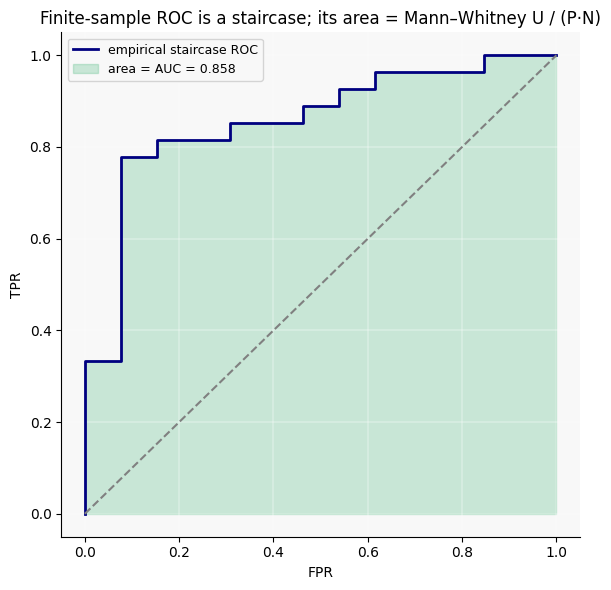

In [ ]:
# Visual: the staircase ROC and its area, on a small sample so steps are visible
small_idx = rng.choice(len(scores), 40, replace=False)
fs, ts = roc_curve_scratch(scores[small_idx], y[small_idx])
fig, ax = plt.subplots(figsize=(6, 6))
ax.step(fs, ts, where="post", color=PALETTE["ink"], lw=2, label="empirical staircase ROC")
ax.fill_between(fs, ts, step="post", alpha=0.25, color=PALETTE["good"],
                label=f"area = AUC = {np.trapezoid(ts, fs):.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Finite-sample ROC is a staircase; its area = Mann–Whitney U / (P·N)")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5 · Why 0.5 is the null

If the two class distributions coincide, $f_1=f_0$, then by symmetry a random positive is
equally likely to be above or below a random negative:

$$P(S_1>S_0)=\tfrac12 \;\Longrightarrow\; \text{AUC}=0.5,$$

and the ROC collapses onto the diagonal. So

$$\text{AUC}=0.5 \iff \text{the score cannot tell the two groups apart at all.}$$

Let's *see* AUC climb from 0.5 as we push the positive class away from the negative class —
the **overlap** of the two densities is the visual stand-in for "indistinguishable."


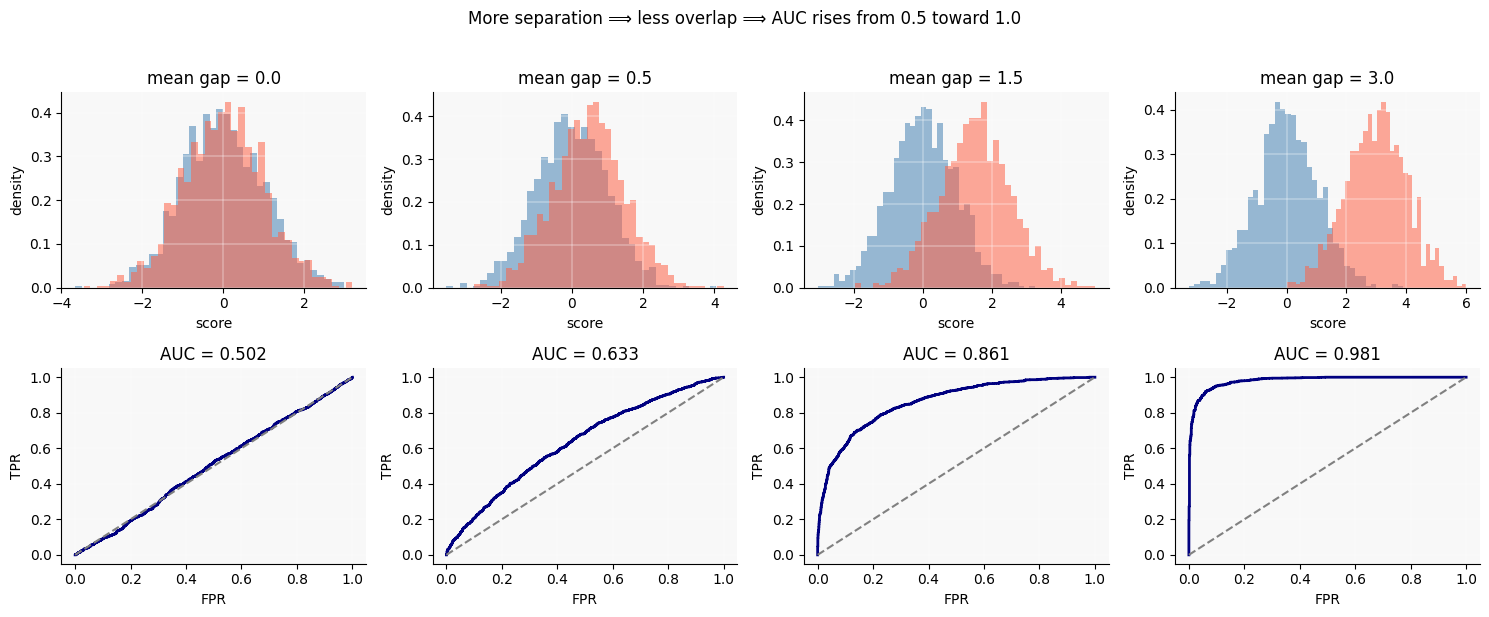

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
gap_grid = [0.0, 0.5, 1.5, 3.0]
xs = np.linspace(-5, 8, 400)
for k, gap in enumerate(gap_grid):
    a = rng.normal(0.0, 1.0, 1500)
    b = rng.normal(gap, 1.0, 1500)
    sc = np.concatenate([b, a]); yy = np.concatenate([np.ones(1500), np.zeros(1500)]).astype(int)
    auc = auc_pairwise(sc, yy)
    f, t = roc_curve_scratch(sc, yy)
    # top row: densities
    ax = axes[0, k]
    ax.hist(a, bins=40, density=True, color=PALETTE["neg"], alpha=0.55)
    ax.hist(b, bins=40, density=True, color=PALETTE["pos"], alpha=0.55)
    ax.set_title(f"mean gap = {gap}")
    ax.set_xlabel("score"); ax.set_ylabel("density"); ax.grid(alpha=0.3)
    # bottom row: ROC
    ax = axes[1, k]
    ax.plot(f, t, color=PALETTE["ink"], lw=2)
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title(f"AUC = {auc:.3f}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.grid(alpha=0.3)
plt.suptitle("More separation ⟹ less overlap ⟹ AUC rises from 0.5 toward 1.0", y=1.02)
plt.tight_layout(); plt.show()

## 6 · Repurposing AUC as a stationarity test (adversarial validation)

Here is the clever move. **Throw away your real target $y$.** Instead, build a *synthetic*
label from **time**:

$$y=0 \;\text{(early block)},\qquad y=1 \;\text{(late block)}.$$

Use a feature's own value as the score $s$. Then AUC answers a new question:

> *Can this feature tell early samples from late samples?*

- $\text{AUC}\approx 0.5$ → early and late look identical → **stationary** → keep the feature.
- $\text{AUC}$ far from $0.5$ → the periods are separable → **the feature has drifted** → drop it.

Swapping the labels sends $\text{AUC}\mapsto 1-\text{AUC}$, so $0.9$ and $0.1$ mean *equally
severe* drift. The quantity you actually threshold is the **drift score**

$$\big|\,\text{AUC}-0.5\,\big|.$$

> **Why this matters in a backtest (🎯 huge in quant interviews):** a feature with stable
> train-period statistics will still describe the test period; a drifting feature teaches the
> model a relationship that **won't survive out-of-sample** — the leakage-adjacent failure mode
> of fitting on non-stationary inputs. Adversarial validation is the standard screen for it.

Let's build a synthetic panel of "factor" features over ~2 years of daily data, with known
behaviour, and let AUC find the drifters.


In [ ]:
# Synthetic feature panel over 504 trading days (~2y)
T = 504
t = np.arange(T)
phase = (t / T)                     # 0 -> 1 across the sample

features = {}
# 1. momentum_21: stationary, mean-reverting noise  -> should be ~0.5
features["momentum_21"] = rng.normal(0, 1, T)
# 2. value_spread: slow upward drift in MEAN        -> AUC far from 0.5
features["value_spread"] = 0.0 + 3.0 * phase + rng.normal(0, 1, T)
# 3. funding_rate: regime shift halfway             -> drift
features["funding_rate"] = np.where(t < T // 2, rng.normal(-1, 0.7, T),
                                                 rng.normal(+1, 0.7, T))
# 4. liquidity: stationary but heavier tails late   -> sneaky (mean stable)
features["liquidity"] = rng.normal(0, 1 + 2.0 * phase, T)   # variance balloons, mean fixed
# 5. carry: mild, borderline trend
features["carry"] = 0.6 * phase + rng.normal(0, 1, T)

# synthetic time label: first half = early(0), second half = late(1)
y_time = (t >= T // 2).astype(int)
print("features:", list(features))
print("early samples:", np.sum(y_time == 0), " late samples:", np.sum(y_time == 1))

features: ['momentum_21', 'value_spread', 'funding_rate', 'liquidity', 'carry']
early samples: 252  late samples: 252


In [ ]:
# Drift score |AUC - 0.5| for each feature against the time label
drift = {name: abs(auc_pairwise(vals, y_time) - 0.5) for name, vals in features.items()}
aucs  = {name: auc_pairwise(vals, y_time) for name, vals in features.items()}

print(f"{'feature':14s} {'AUC':>7s} {'|AUC-0.5|':>11s}   verdict")
for name in features:
    flag = "DROP (drifted)" if drift[name] > 0.15 else "keep (stationary)"
    print(f"{name:14s} {aucs[name]:7.3f} {drift[name]:11.3f}   {flag}")

feature            AUC   |AUC-0.5|   verdict
momentum_21      0.515       0.015   keep (stationary)
value_spread     0.845       0.345   DROP (drifted)
funding_rate     0.980       0.480   DROP (drifted)
liquidity        0.501       0.001   keep (stationary)
carry            0.591       0.091   keep (stationary)


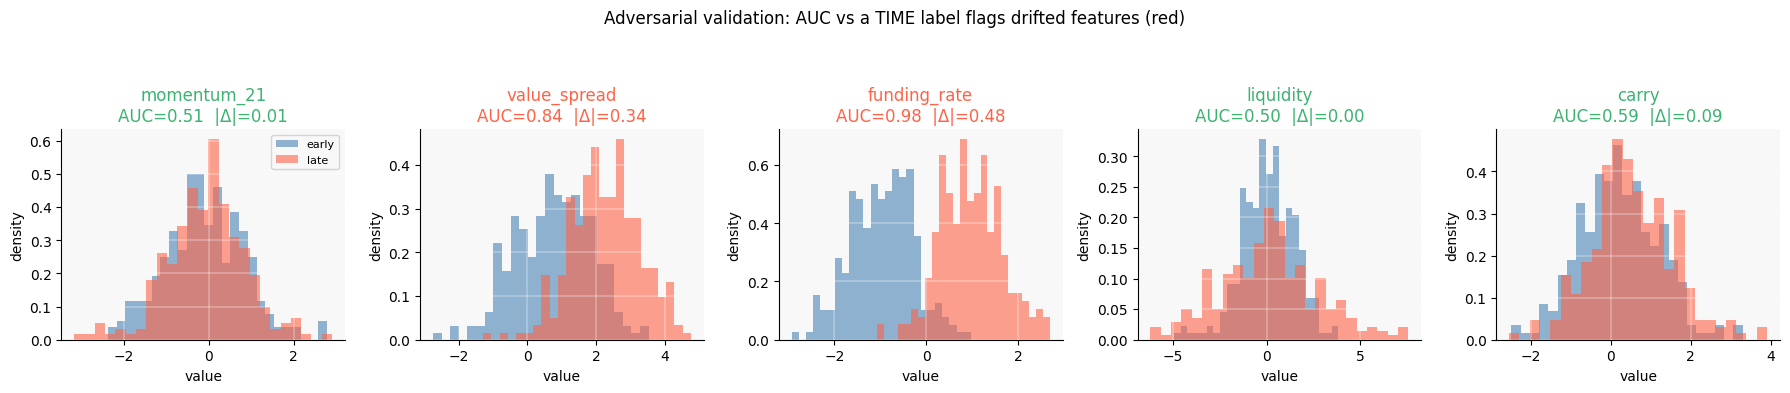

In [ ]:
# Visualize: each feature's early vs late distribution + its drift score
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, name in zip(axes, features):
    vals = features[name]
    ax.hist(vals[y_time == 0], bins=25, density=True, color=PALETTE["neg"], alpha=0.6, label="early")
    ax.hist(vals[y_time == 1], bins=25, density=True, color=PALETTE["pos"], alpha=0.6, label="late")
    bad = drift[name] > 0.15
    ax.set_title(f"{name}\nAUC={aucs[name]:.2f}  |Δ|={drift[name]:.2f}",
                 color=("tomato" if bad else "mediumseagreen"))
    ax.set_xlabel("value"); ax.set_ylabel("density"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.suptitle("Adversarial validation: AUC vs a TIME label flags drifted features (red)", y=1.08)
plt.tight_layout(); plt.show()

Notice `value_spread` and `funding_rate` light up (mean shift / regime change), while
`momentum_21` sits right at 0.5. But look carefully at **`liquidity`** — its early and late
*means* are identical, yet its spread explodes. Does AUC catch it? Let's interrogate that.

## 7 · Rolling drift across trimonthly blocks

In practice you don't just split once — you compare **blocks** (e.g. trimonthly) so you can see
*when* a feature breaks. Compare each later block against the first block; track $|AUC-0.5|$.


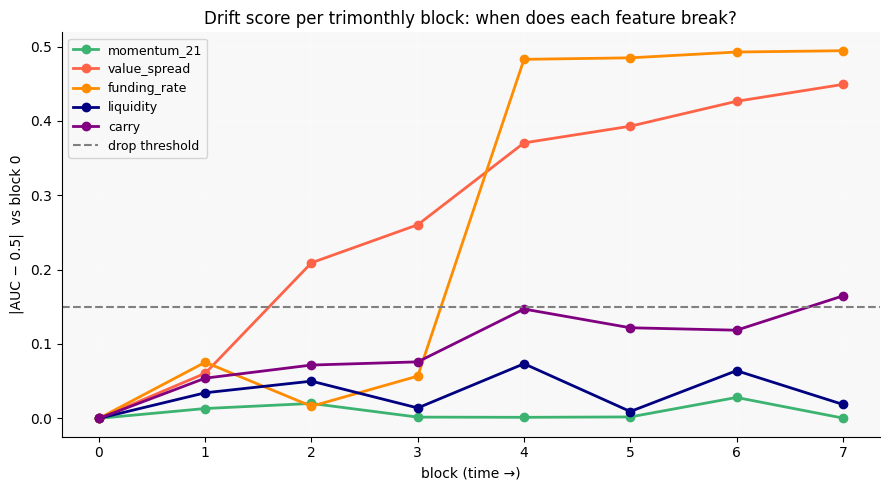

In [ ]:
n_blocks = 8                                  # ~ trimonthly over 2y
block_id = np.minimum((t // (T // n_blocks)), n_blocks - 1)

def block_drift(vals, ref_block=0):
    ref = vals[block_id == ref_block]
    out = []
    for b in range(n_blocks):
        cur = vals[block_id == b]
        sc = np.concatenate([cur, ref])
        yy = np.concatenate([np.ones(len(cur)), np.zeros(len(ref))]).astype(int)
        out.append(abs(auc_pairwise(sc, yy) - 0.5))
    return np.array(out)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE["good"], PALETTE["pos"], PALETTE["warn"], PALETTE["ink"], "purple"]
for (name, vals), c in zip(features.items(), colors):
    ax.plot(range(n_blocks), block_drift(vals), "o-", color=c, lw=2, label=name)
ax.axhline(0.15, ls="--", color="gray", label="drop threshold")
ax.set_xlabel("block (time →)"); ax.set_ylabel("|AUC − 0.5|  vs block 0")
ax.set_title("Drift score per trimonthly block: when does each feature break?")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

`funding_rate` stays flat until the regime shift at the midpoint, then jumps — exactly
the diagnostic you want. `value_spread` and `carry` ramp gradually. `momentum_21` hugs zero.

## 8 · The blind spot: symmetric variance blow-ups

AUC only sees what a **monotone score** can separate. If a feature's distribution stays
**centered** but its variance balloons *symmetrically*, then a random "late" value is still
equally likely to be above or below a random "early" value — so

$$P(S_\text{late} > S_\text{early}) \approx \tfrac12 \;\Rightarrow\; \text{AUC}\approx 0.5,$$

**even though the feature has clearly changed.** That is our `liquidity` feature.

> **Key insight:** AUC is a *location/ranking* detector. It is blind to pure dispersion changes
> that keep the median fixed. To close the gap, pair it with a **distance between distributions**
> that does see spread — the **1-Wasserstein (earth-mover) distance**.

The 1-Wasserstein distance between two empirical samples (sorted) is simply

$$W_1=\frac{1}{n}\sum_i \big| x_{(i)} - z_{(i)} \big|,$$

the average gap between matched order statistics — it grows when *either* the location *or* the
spread changes. Let's show AUC missing the variance shift while $W_1$ catches it.


In [ ]:
def wasserstein1(a, b):
    '''1-D 1-Wasserstein distance via sorted order statistics (equal-size or interp).'''
    a = np.sort(a); b = np.sort(b)
    n = max(len(a), len(b))
    qa = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(a)), a)
    qb = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(b)), b)
    return np.mean(np.abs(qa - qb))

print(f"{'feature':14s} {'|AUC-0.5|':>10s} {'Wasserstein':>12s}")
for name, vals in features.items():
    early, late = vals[y_time == 0], vals[y_time == 1]
    print(f"{name:14s} {abs(auc_pairwise(vals, y_time)-0.5):10.3f} {wasserstein1(early, late):12.3f}")

feature         |AUC-0.5|  Wasserstein
momentum_21         0.015        0.097
value_spread        0.345        1.516
funding_rate        0.480        1.928
liquidity           0.001        0.933
carry               0.091        0.328


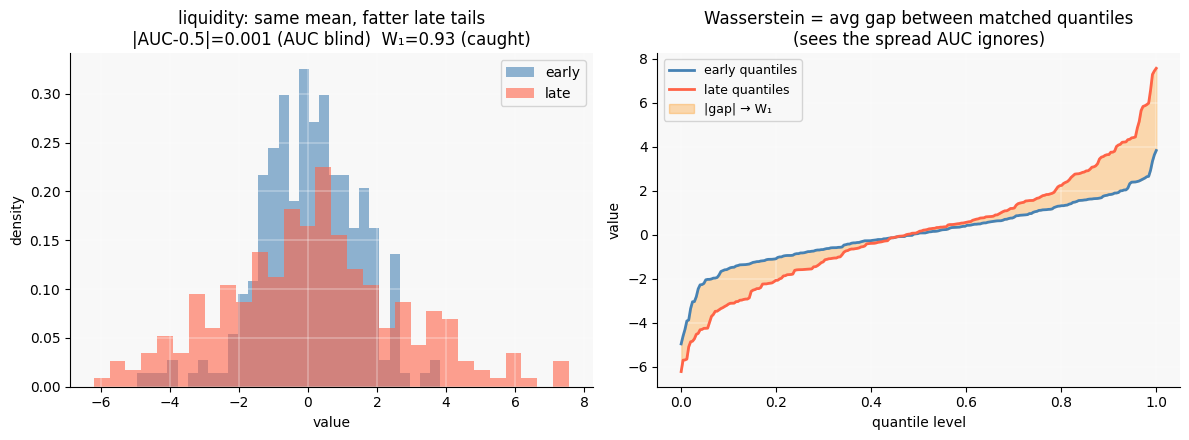

In [ ]:
# Focus on liquidity: AUC says 'fine', Wasserstein says 'drifted'
early, late = features["liquidity"][y_time == 0], features["liquidity"][y_time == 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(early, bins=30, density=True, color=PALETTE["neg"], alpha=0.6, label="early")
axes[0].hist(late,  bins=30, density=True, color=PALETTE["pos"], alpha=0.6, label="late")
axes[0].set_title(f"liquidity: same mean, fatter late tails\n"
                  f"|AUC-0.5|={abs(auc_pairwise(features['liquidity'], y_time)-0.5):.3f} (AUC blind)  "
                  f"W₁={wasserstein1(early, late):.2f} (caught)")
axes[0].set_xlabel("value"); axes[0].set_ylabel("density")
axes[0].legend(); axes[0].grid(alpha=0.3)

# the sorted-quantile picture behind Wasserstein
qa = np.sort(early); qb = np.sort(late)
n = min(len(qa), len(qb)); g = np.linspace(0, 1, n)
axes[1].plot(g, np.interp(g, np.linspace(0,1,len(qa)), qa), color=PALETTE["neg"], lw=2, label="early quantiles")
axes[1].plot(g, np.interp(g, np.linspace(0,1,len(qb)), qb), color=PALETTE["pos"], lw=2, label="late quantiles")
axes[1].fill_between(g, np.interp(g, np.linspace(0,1,len(qa)), qa),
                        np.interp(g, np.linspace(0,1,len(qb)), qb),
                        color=PALETTE["warn"], alpha=0.3, label="|gap| → W₁")
axes[1].set_title("Wasserstein = avg gap between matched quantiles\n(sees the spread AUC ignores)")
axes[1].set_xlabel("quantile level"); axes[1].set_ylabel("value")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

> **Takeaway:** AUC ($|AUC-0.5|$) is your first-line, scale-invariant, location/ranking drift
> screen; a Wasserstein (or KS) monitor on dispersion closes its variance blind spot. Run both. 🎯

## 9 · (Optional) Interactive: watch AUC respond to mean vs variance drift

Slide the **mean shift** and the **variance ratio** between the "early" and "late" groups.
You'll feel AUC react strongly to the mean but barely to symmetric variance — while
Wasserstein reacts to both.


In [ ]:
try:
    from ipywidgets import interact, FloatSlider

    def demo(mean_shift=1.0, var_ratio=1.0):
        a = rng.normal(0, 1, 2000)
        b = rng.normal(mean_shift, np.sqrt(var_ratio), 2000)
        sc = np.concatenate([b, a]); yy = np.concatenate([np.ones(2000), np.zeros(2000)]).astype(int)
        auc = auc_pairwise(sc, yy); w = wasserstein1(a, b)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(a, bins=40, density=True, color=PALETTE["neg"], alpha=0.6, label="early")
        ax.hist(b, bins=40, density=True, color=PALETTE["pos"], alpha=0.6, label="late")
        ax.set_title(f"|AUC-0.5| = {abs(auc-0.5):.3f}   |   W₁ = {w:.3f}")
        ax.set_xlabel("value"); ax.set_ylabel("density"); ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    interact(demo,
             mean_shift=FloatSlider(min=0, max=4, step=0.25, value=1.0),
             var_ratio=FloatSlider(min=0.25, max=9, step=0.25, value=1.0))
except Exception as e:
    print("ipywidgets not available — skipping interactive cell:", e)

interactive(children=(FloatSlider(value=1.0, description='mean_shift', max=4.0, step=0.25), FloatSlider(value=…

## 10 · Summary

| Concept | Key Idea |
|---|---|
| **Confusion matrix** | One threshold $\tau$ → counts (TP, FP, FN, TN). |
| **TPR / FPR** | Row-normalized rates = $\widehat P(s\ge\tau\mid y{=}1)$ and $\widehat P(s\ge\tau\mid y{=}0)$; immune to class imbalance. |
| **ROC curve** | Sweep $\tau$ over all values → trajectory $(\text{FPR},\text{TPR})$; threshold-free view of separability. |
| **AUC integral** | $\int_0^1 \text{TPR}\,d\text{FPR}$ = area under that trajectory. |
| **AUC meaning** 🎯 | $\text{AUC}=P(S_1>S_0)$ — chance a random positive outranks a random negative. |
| **Mann–Whitney U** 🎯 | Empirical AUC = normalized U-statistic; the ½-tie term = trapezoid half-steps. |
| **Rank invariance** | AUC depends only on ranks ⇒ unchanged by any monotone transform (e.g. quantile scaling). |
| **Null = 0.5** | $f_1=f_0 \Rightarrow$ AUC $=0.5$; the score is uninformative. |
| **Adversarial validation** 🎯 | Relabel by time (early=0, late=1); feature-as-score AUC tests stationarity. |
| **Drift score** | Threshold on $|\text{AUC}-0.5|$ (label-swap symmetric); near 0 = keep, large = drop. |
| **Blind spot** | Symmetric variance change keeps AUC ≈ 0.5; pair with **Wasserstein/KS** to catch dispersion drift. |

### Interview soundbites to memorize
- *"AUC is the probability a random positive ranks above a random negative."*
- *"AUC equals the Mann–Whitney U statistic, rescaled — it's a nonparametric two-sample test."*
- *"AUC is rank-invariant, so monotone scaling never changes it."*
- *"Adversarial validation = train a classifier to tell train from test; AUC≈0.5 means they're
  exchangeable, AUC≫0.5 means covariate shift / drift."*
- *"AUC is a location detector and is blind to symmetric variance change — back it with Wasserstein."*
